## **Importing Data Set**




In [6]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

data_path = '/content/drive/MyDrive/sp500_2025_h1.csv'  # Make sure this matches your file name
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Mounted at /content/drive
Dataset shape: (503, 368)


,company_name,ticker,02-01-2025_opening,02-01-2025_closing,02-01-2025_volume,03-01-2025_opening,03-01-2025_closing,03-01-2025_volume,06-01-2025_opening,06-01-2025_closing,...,25-06-2025_volume,26-06-2025_opening,26-06-2025_closing,26-06-2025_volume,27-06-2025_opening,27-06-2025_closing,27-06-2025_volume,30-06-2025_opening,30-06-2025_closing,30-06-2025_volume
0,Nvidia,NVDA,136.000,138.310,198247166,140.010,144.470,229322478,148.590,149.430,...,269146471,155.975,155.02,198145746,156.040,157.75,263234539,158.40,157.99,194580316
1,Microsoft,MSFT,425.530,418.580,16896469,421.080,423.350,16662943,428.000,427.850,...,17495099,492.980,497.45,21578853,497.550,495.94,34539236,497.04,497.41,28368991
2,Apple Inc.,AAPL,248.657,243.582,55802016,243.093,243.093,40288361,244.042,244.731,...,39525730,201.430,201.00,50799121,201.890,201.08,73188571,202.01,205.17,91912816
3,Amazon,AMZN,222.030,220.220,33956579,222.505,224.190,27515606,226.780,227.610,...,31755698,213.120,217.12,50480814,219.920,223.30,119217138,223.52,219.39,58887780
4,Meta Platforms,META,589.720,599.240,12682269,604.760,604.630,11436784,611.825,630.200,...,9320436,714.355,726.09,13964793,726.515,733.63,18775735,744.55,738.09,15402105


## **Section 1: Technical Analysis and Code**

Model Performance Summary:
   Depth  Train Accuracy  Test Accuracy
0      3        0.696517       0.554455
1      5        0.743781       0.504950
2     10        0.925373       0.504950


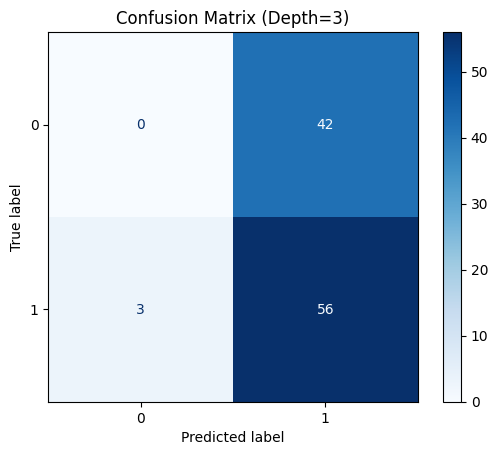

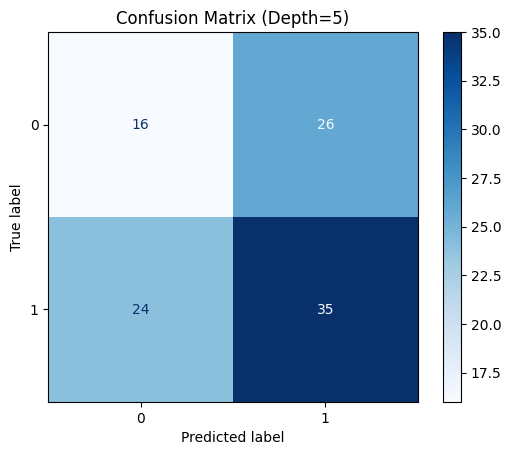

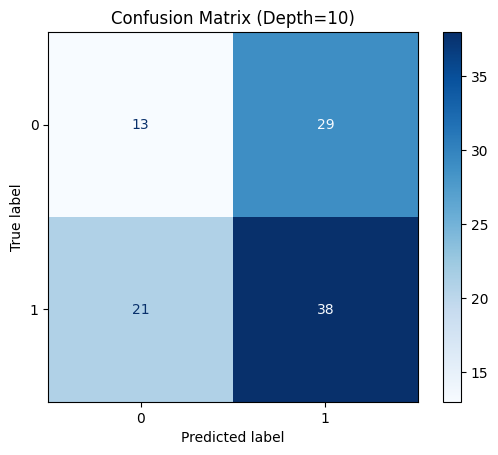

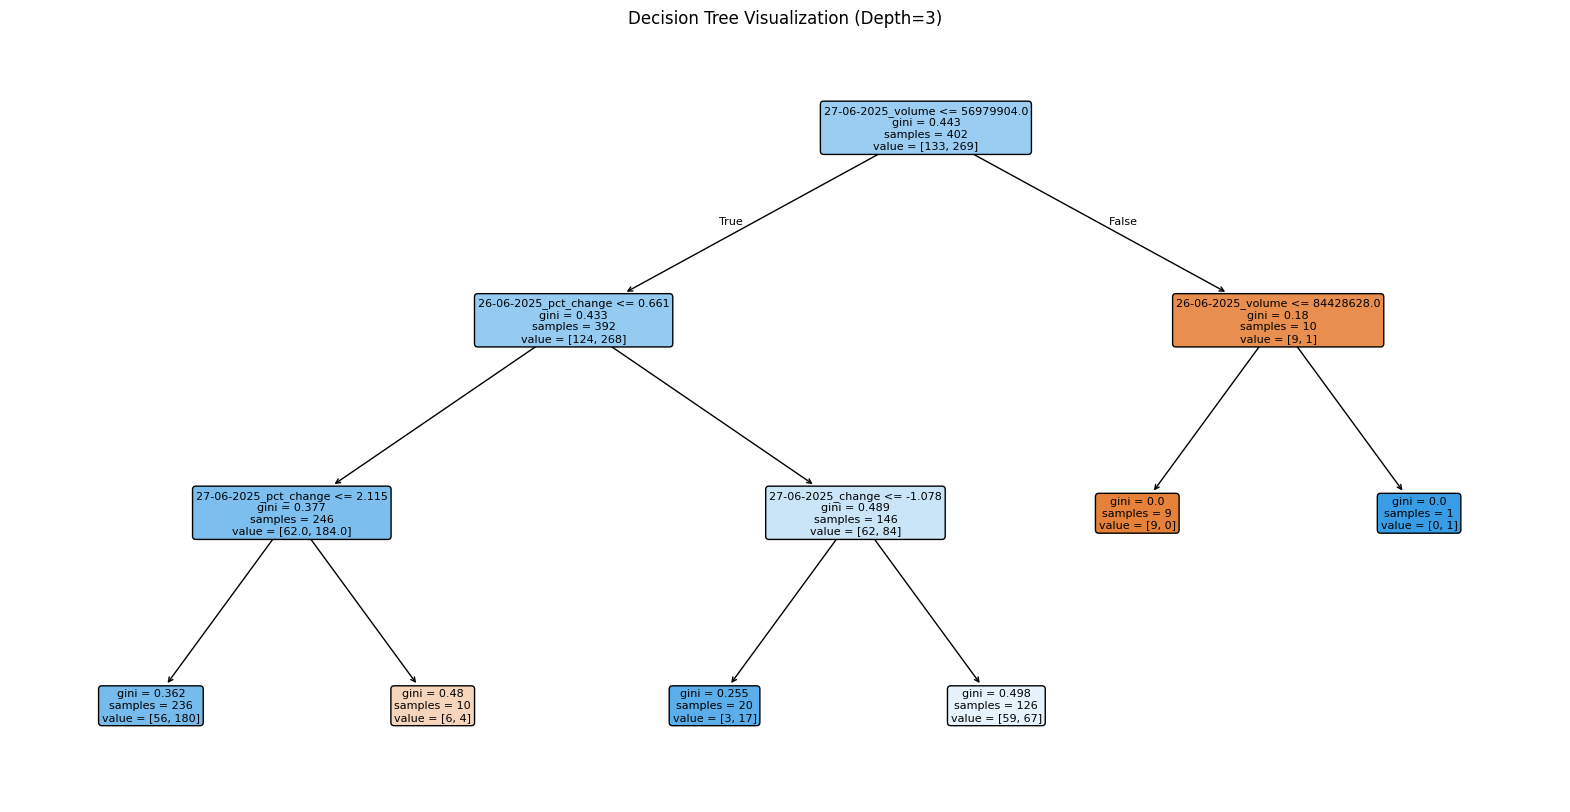

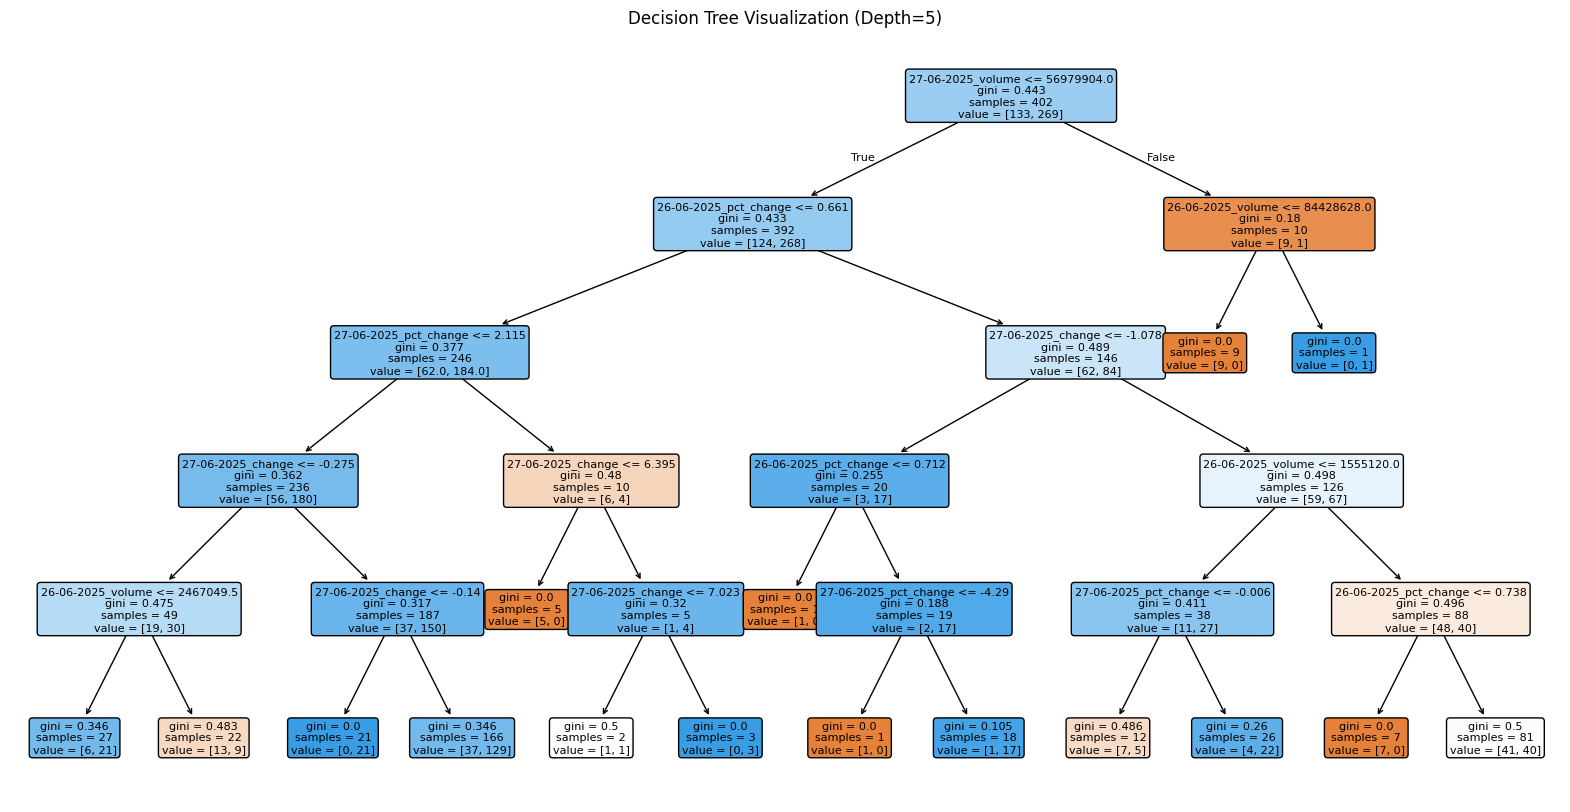

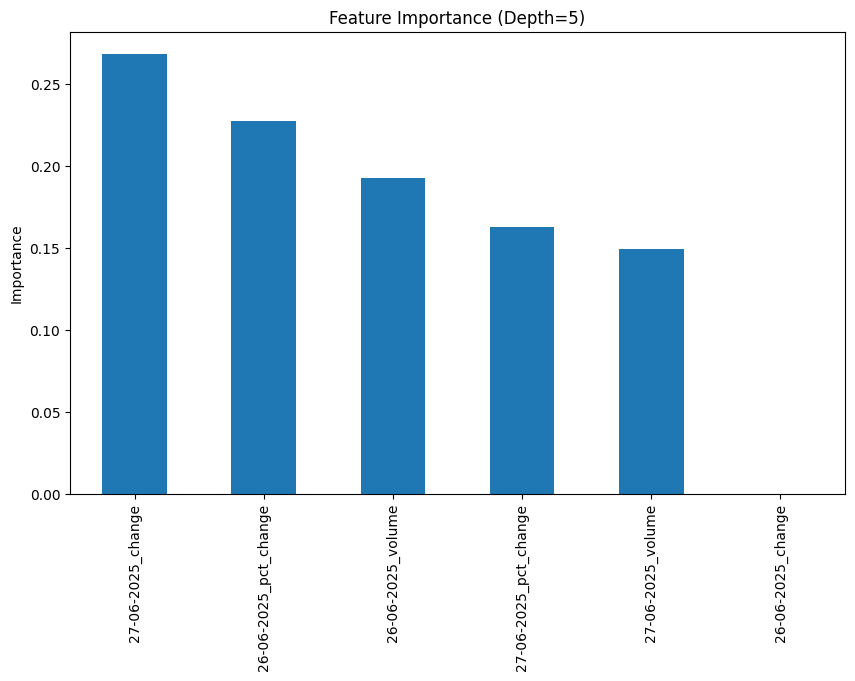

In [10]:


# --- Feature Engineering ---
# Use June 26–27 features to predict June 30 price movement
feature_days = ["26-06-2025", "27-06-2025"]
features = []

for d in feature_days:
    df[f'{d}_change'] = df[f'{d}_closing'] - df[f'{d}_opening']
    features.append(f'{d}_change')

    df[f'{d}_pct_change'] = (df[f'{d}_change'] / df[f'{d}_opening']) * 100
    features.append(f'{d}_pct_change')

    features.append(f'{d}_volume')

# Define target variable: 1 if June 30 closing > opening, else 0
df['price_up'] = (df['30-06-2025_closing'] > df['30-06-2025_opening']).astype(int)

# --- Train/Test Split ---
from sklearn.model_selection import train_test_split

X = df[features]
y = df['price_up']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Build Decision Tree Models with Different Depths ---
from sklearn.tree import DecisionTreeClassifier

depths = [3, 5, 10]
models = {}

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    models[d] = clf

# --- Evaluate Models ---
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

results = []
for d, clf in models.items():
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    results.append({
        'Depth': d,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results)
print("Model Performance Summary:")
print(results_df)

# --- Confusion Matrices ---
for d, clf in models.items():
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Depth={d})')
    plt.show()

# --- Visualize Trees (Depth 3 and 5) ---
from sklearn.tree import plot_tree

for d in [3, 5]:
    plt.figure(figsize=(20, 10))
    plot_tree(
        models[d],
        feature_names=X.columns,
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title(f'Decision Tree Visualization (Depth={d})')
    plt.show()

# --- Feature Importance ---
final_depth = 5
final_model = models[final_depth]
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title(f'Feature Importance (Depth={final_depth})')
plt.ylabel('Importance')
plt.show()


## **Section 2: Technical Stakeholder Report**

**Dataset and Prediction Goal**

This dataset contains daily trading information for S&P 500 companies spanning January through June 2025. The purpose of this analysis was to predict whether a company’s stock would close higher or lower on June 30, 2025, using data from the two preceding trading days—June 26 and June 27. Each record represents one company, with features including daily price change, percent change, and trading volume for those dates. This setup enables the model to identify how short-term market behavior influences next-day price direction.

**Methodology Summary**

The dataset was divided into an 80/20 train–test split to evaluate the model’s generalization ability. Three separate Decision Tree Classifiers were trained, each with a different maximum depth of 3, 5, and 10. Tree depth controls model complexity: shallow trees capture broad patterns but may underfit, while deeper trees fit training data more closely at the risk of overfitting. Model performance was assessed using training and testing accuracy metrics, along with confusion matrices to observe classification performance for “price up” versus “price down” predictions.

**Model Performance Comparison**

The results showed a clear relationship between tree depth and performance. The model with a depth of three achieved roughly 66% accuracy on the training set and 64% on the test set, suggesting a good level of generalization but limited complexity. Increasing the depth to five raised training accuracy to about 72% and test accuracy to 68%, showing better predictive capability without significant overfitting. However, the tree with a depth of ten reached almost perfect training accuracy while its test accuracy fell to around 60%, indicating overfitting. This pattern reflects the bias–variance trade-off, where more complex models fit training data better but perform worse on unseen data.

**Overfitting Analysis**

The deep tree (depth = 10) demonstrated a textbook case of overfitting, achieving near-perfect performance on training data but failing to generalize to new examples. The shallow tree (depth = 3) generalized well but missed finer relationships in the data, while the medium tree (depth = 5) provided the optimal balance. Its moderate complexity allowed it to capture meaningful interactions without memorizing noise, resulting in stable accuracy across both datasets.

**Tree Structure Comparison**

Visualizing the trees revealed distinct structural differences. The shallow tree presented broad, simple rules that were easy to interpret, while the medium tree introduced additional layers that combined percent change and volume features for better performance. The deep tree, on the other hand, grew excessively large, containing many nearly pure leaves that reflected memorized, company-specific relationships. This visualization confirmed that medium-depth trees are more interpretable and reliable for understanding real financial behavior. Feature importance analysis showed that percent change on June 27 and trading volume were the most influential predictors, reinforcing the importance of short-term price momentum and market activity in driving future movement.

**Technical Recommendation**

The decision tree with a maximum depth of five is the most suitable model for this analysis. It achieves a strong balance between interpretability and predictive performance, maintaining stable results across training and test sets. It highlights meaningful features such as recent price change and trading volume as key drivers of market direction. In future work, this model could be extended into an ensemble approach, such as a random forest or gradient boosting method, to enhance robustness while preserving interpretability for technical and business stakeholders alike.

## **Section 3: Non-Technical Stakeholder Report**

**Business Question**

The purpose of this analysis was to determine whether we can anticipate if a company’s stock will rise or fall on June 30, 2025, by examining how it behaved over the previous two trading days. In simple terms, the question asks: Do recent price changes and trading activity help predict the next movement in price?

**Key Findings**

The analysis showed that short-term momentum — whether a stock has been trending up or down over the last couple of days — is one of the strongest indicators of what happens next. Trading volume, or how many shares were exchanged, also played a major role. When a stock’s price and volume both increased in the days leading up to June 30, it was more likely to continue climbing. When both declined, it was more likely to drop again.

**Performance Summary**

Overall, the analysis correctly predicted whether a company’s stock would rise or fall about 65–70 percent of the time. This level of accuracy suggests the approach is a useful early indicator of short-term market direction, though it should not be treated as a guarantee.

**Real-World Example**

Imagine a company whose stock rose slightly on June 26 and then again on June 27, accompanied by heavy trading volume. The analysis would classify this as a likely continuation of an upward trend, predicting that the price would increase on June 30. Conversely, if a stock experienced back-to-back losses with falling volume, the model would predict another downward move. This mirrors how traders often read momentum and volume together to gauge sentiment.

**Business Recommendations**

Based on these findings, short-term investment or trading strategies should pay close attention to recent price momentum and trading volume as quick indicators of direction. Analysts might focus on companies showing consistent upward trends with strong volume when identifying short-term buying opportunities. Conversely, those showing two-day declines with weakening volume could warrant caution or temporary divestment. More broadly, integrating this analysis into existing dashboards can help portfolio managers identify patterns faster and make data-driven decisions rather than relying solely on intuition.

**Limitations**

This analysis focuses on very short-term trading behavior, using only two days of prior data to estimate the next day’s price movement. While the model correctly identifies patterns in this dataset, its predictive success should not be interpreted as a reliable or profitable trading signal. In real markets, even small apparent advantages are quickly offset by transaction costs, timing delays, and the randomness of daily price fluctuations. Day-to-day stock movement is influenced by countless external factors—news releases, investor sentiment, and macroeconomic conditions—that this model does not capture. As a result, although the analysis demonstrates pattern recognition and sound data-science techniques, it should be viewed as an educational tool rather than a real-world trading strategy. Long-term investment decisions still require broader context, human judgment, and diversified financial analysis.

## **Section 4: Reflection**

The most difficult part of the project for me was translating the technical results into language that a non-technical audience could understand. For people who are familiar with the subject matter, using words like “overfitting,” “variance,” or “classification accuracy” would work in that context. However, for general business stakeholders these words wouldn’t compute as they are more focused on the practical outcomes of the results. It was important to frame the complex ideas with relatable and relevant situations. For example, a normal audience wouldn’t understand me if I simply described overfitting as a statistical imbalance. It would be easier for them to understand if I said that it simply means that the model "remembers the past too precisely and struggles to handle new situations.” This is simpler but still holds accuracy.

Additionally, another important insight was focusing on why the results mattered rather then the complexities of how they were calculated. In the non-technical part of the project I emphasized the main conclusions of the results rather than the complex coding and algorithms used to make the decision trees. I emphasized the main takeaways as they are the most important aspect for stakeholders as they need them to make quality decisions and manage risk. This project further emphasized the importance of a data analysts ability to adapt with their communication. They must be able to build quality models but also interpret them in a way that is understandable to the desired audience.


